In [6]:
# import required libraries

import pandas as pd
import numpy as np

In [7]:
# load the dataset

df = pd.read_csv("E:/vscode/Resume Screening_Additional project/AI_Resume_Screening.csv")


In [8]:
# check first few rows

df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [9]:
# check missing values

df.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [10]:
# check duplicates

print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [11]:
# check and fill missing values 

df['Skills'] = df['Skills'].fillna('none')
df['Education'] = df['Education'].fillna('unknown')
df['Certifications'] = df['Certifications'].fillna('none')
df['Projects Count'] = df['Projects Count'].fillna(0)
df['Job Role'] = df['Job Role'].fillna('unknown')
df['Experience (Years)'] = df['Experience (Years)'].fillna(df['Experience (Years)'].median())

In [12]:
# check datatypes of each column using info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Resume_ID               1000 non-null   int64
 1   Name                    1000 non-null   str  
 2   Skills                  1000 non-null   str  
 3   Experience (Years)      1000 non-null   int64
 4   Education               1000 non-null   str  
 5   Certifications          1000 non-null   str  
 6   Job Role                1000 non-null   str  
 7   Recruiter Decision      1000 non-null   str  
 8   Salary Expectation ($)  1000 non-null   int64
 9   Projects Count          1000 non-null   int64
 10  AI Score (0-100)        1000 non-null   int64
dtypes: int64(5), str(6)
memory usage: 163.3 KB


In [13]:
# drop the least required columns

df = df.drop(['Resume_ID', 'Name', 'Recruiter Decision', 'Salary Expectation ($)'], axis=1)

In [14]:
# check if the columns are ropped

df

,Skills,Experience (Years),Education,Certifications,Job Role,Projects Count,AI Score (0-100)
0,"TensorFlow, NLP, Pytorch",10,B.Sc,none,AI Researcher,8,100
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,1,100
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,7,70
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,0,95
4,"SQL, React, Java",4,PhD,none,Software Engineer,9,100
...,...,...,...,...,...,...,...
995,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,none,Cybersecurity Analyst,9,60
996,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,5,45
997,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,9,65
998,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,10,100


In [15]:
# standardizing text values

# 1. Converting skills to lowercase AND fixing messy comma spacing
df['Skills'] = df['Skills'].str.lower()
df['Skills'] = df['Skills'].str.replace(r'\s*,\s*', ', ', regex=True).str.strip()


# 2. Remove extra spacings in job role (both edges and internal double-spaces)
df['Job Role'] = df['Job Role'].str.lower().str.strip()
df['Job Role'] = df['Job Role'].str.replace(r'\s+', ' ', regex=True)


# 3. Define mapping dictionaries (CRITICAL: Keys must be lowercase to match steps 2 & 4)
job_map = {
    'ai researcher': 'ai researcher', 
    'data scientist': 'data scientist', 
    'cybersecurity analyst': 'cybersecurity analyst', 
    'software engineer': 'software engineer'
}

edu_map = {
    'b.sc': 'bsc', 
    'mba': 'mba', 
    'b.tech': 'btech', 
    'phd': 'phd', 
    'm.tech': 'mtech'
}

certification_map = {
    'deep learning specialization': 'data_science', 
    'google ml': 'data_science', 
    'aws certified': 'cloud', 
    'none': 'none'
}


# 4. Apply mapping to Job Role and Education
df['Job Role'] = df['Job Role'].replace(job_map)
df['Education'] = df['Education'].str.lower().str.strip().replace(edu_map)


# 5. Standardize Certifications (Lowercase, strip, map variations, then apply main mapping)
df['Certifications'] = df['Certifications'].str.lower().str.strip()
df['Certifications'] = df['Certifications'].str.replace(r'\s+', ' ', regex=True)
df['Certifications'] = df['Certifications'].str.replace('aws certification', 'aws certified') # Fix variations first
df['Certifications'] = df['Certifications'].replace(certification_map) # Apply broad groups (e.g., cloud)

In [16]:
# preprocessing

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

# 1) converting education into numerics using ordinal encoding

education_order = [['unknown', 'bsc', 'btech', 'mba', 'mtech', 'phd']]

encoder = OrdinalEncoder(categories=education_order)

df['Education_Encoded'] = encoder.fit_transform(df[['Education']]).astype(int)

In [17]:
# checking id education encoding done correctly 

df[['Education', 'Education_Encoded']].head()

,Education,Education_Encoded
0,bsc,1
1,mba,3
2,mba,3
3,btech,2
4,phd,5


In [18]:
# 2) using label encoding convert job role and certifications

le_cert = LabelEncoder()
le_job = LabelEncoder()

df['Certifications_Encoded'] = le_cert.fit_transform(df['Certifications'])
df['Job Role_Encoded'] = le_job.fit_transform(df['Job Role'])

In [19]:
# checking if label encoding done properly

df[['Certifications', 'Certifications_Encoded']].tail(10)
# df[['Job Role', 'Job Role_Encoded']].head(10)

,Certifications,Certifications_Encoded
990,data_science,1
991,data_science,1
992,data_science,1
993,data_science,1
994,data_science,1
995,none,2
996,data_science,1
997,data_science,1
998,cloud,0
999,data_science,1


In [20]:
# 3) counting skills column

# Count commas and add 1 to get the total number of skills per row
df['Skills_Count'] = df['Skills'].str.count(',') + 1

# If a row is completely empty/missing, set the count to 0
df['Skills_Count'] = df['Skills_Count'].fillna(0).astype(int)

# Check your work side-by-side
print(df[['Skills', 'Skills_Count']].head())

                                         Skills  Skills_Count
0                      tensorflow, nlp, pytorch             3
1  deep learning, machine learning, python, sql             4
2         ethical hacking, cybersecurity, linux             3
3                   python, pytorch, tensorflow             3
4                              sql, react, java             3


In [21]:
# verify the columns before proceeding to modeling

df.columns

Index(['Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role', 'Projects Count', 'AI Score (0-100)', 'Education_Encoded',
       'Certifications_Encoded', 'Job Role_Encoded', 'Skills_Count'],
      dtype='str')

In [22]:
# keeping only encoded featured for train test split

df = df.drop(columns=['Education', 'Certifications', 'Job Role', 'Skills'])
df.columns

Index(['Experience (Years)', 'Projects Count', 'AI Score (0-100)',
       'Education_Encoded', 'Certifications_Encoded', 'Job Role_Encoded',
       'Skills_Count'],
      dtype='str')

In [23]:
# creating x & y

x = df.drop('AI Score (0-100)', axis = 1)
y = df['AI Score (0-100)']


In [24]:
# check x & y shape

x.shape, y.shape

((1000, 6), (1000,))

In [25]:
# train test split

from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state=42)

In [26]:
# check train test shapes of x & y

print(f"x_train_shape: {x_train.shape} | x_test_shape: {x_test.shape} | y_train_shape: {y_train.shape} | y_test_shape: {y_test.shape}")

x_train_shape: (800, 6) | x_test_shape: (200, 6) | y_train_shape: (800,) | y_test_shape: (200,)


In [27]:
# scaling the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [ ]:
# training the model using different regression models (scaled data)

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary of models:

models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Support Vector Regression": SVR(),
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


Linear Regression -> MAE: 8.52, RMSE: 10.17, R2: 0.81
KNN Regressor -> MAE: 5.18, RMSE: 7.85, R2: 0.88
Support Vector Regression -> MAE: 7.41, RMSE: 11.05, R2: 0.77


In [29]:
# training the model using different regression models (unscaled data)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Decision tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


Decision tree -> MAE: 2.05, RMSE: 4.33, R2: 0.96
Random Forest -> MAE: 1.69, RMSE: 2.87, R2: 0.98
XGBoost -> MAE: 1.04, RMSE: 1.75, R2: 0.99


In [30]:
# create a dataframe of the model performances

import pandas as pd

# 1. Structure the metrics into a dictionary
data = {
    'Model': [
        'Linear Regression', 
        'KNN Regressor', 
        'Support Vector Regression', 
        'Decision Tree', 
        'Random Forest', 
        'XGBoost'
    ],
    'MAE': [8.52, 5.18, 7.41, 2.05, 1.69, 1.04],
    'RMSE': [10.17, 7.85, 11.05, 4.33, 2.87, 1.75],
    'R2_Score': [0.81, 0.88, 0.77, 0.96, 0.98, 0.99]
}

# 2. Create the DataFrame
df_metrics = pd.DataFrame(data)

# 3. Display the DataFrame
print(df_metrics)

                       Model   MAE   RMSE  R2_Score
0          Linear Regression  8.52  10.17      0.81
1              KNN Regressor  5.18   7.85      0.88
2  Support Vector Regression  7.41  11.05      0.77
3              Decision Tree  2.05   4.33      0.96
4              Random Forest  1.69   2.87      0.98
5                    XGBoost  1.04   1.75      0.99


C:\Users\tejas\AppData\Local\Temp\ipykernel_9576\2537137838.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score', y='Model', data=df_sorted, palette='viridis', ax=ax1)


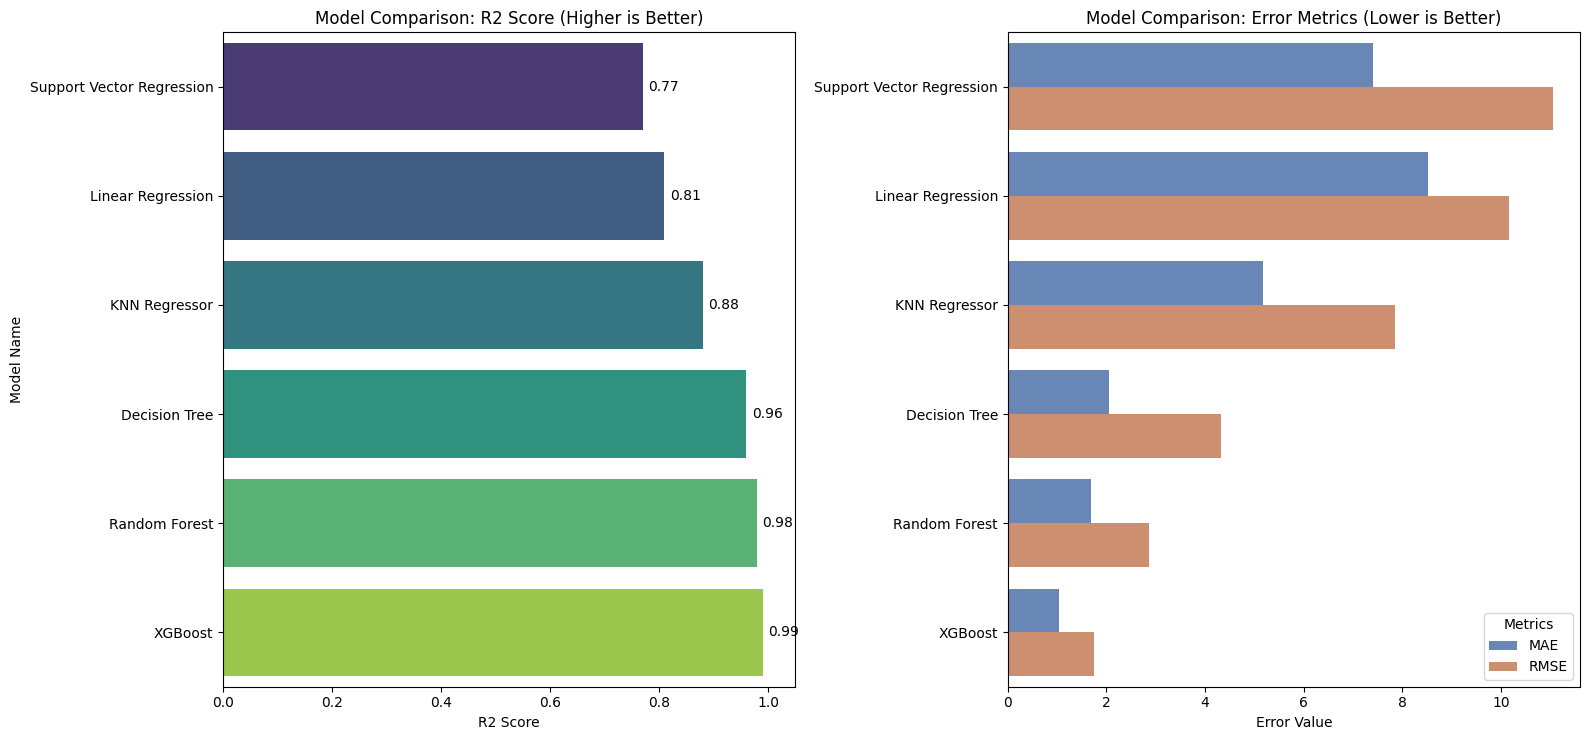

In [31]:
# model comparision bar chart 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recreate your dataset
data = {
    'Model': [
        'Linear Regression', 
        'KNN Regressor', 
        'Support Vector Regression', 
        'Decision Tree', 
        'Random Forest', 
        'XGBoost'
    ],
    'MAE': [8.52, 5.18, 7.41, 2.05, 1.69, 1.04],
    'RMSE': [10.17, 7.85, 11.05, 4.33, 2.87, 1.75],
    'R2_Score': [0.81, 0.88, 0.77, 0.96, 0.98, 0.99]
}
df = pd.DataFrame(data)

# 2. Sort the data by R2 Score in ascending order to match your image exactly
# (SVR at the top, XGBoost at the bottom)
df_sorted = df.sort_values(by='R2_Score', ascending=True)

# 3. Initialize the side-by-side layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

# --- PLOT 1: Horizontal R2 Score (Sequential Colors) ---
sns.barplot(x='R2_Score', y='Model', data=df_sorted, palette='viridis', ax=ax1)
ax1.set_title('Model Comparison: R2 Score (Higher is Better)', fontsize=12)
ax1.set_xlabel('R2 Score')
ax1.set_ylabel('Model Name')
ax1.set_xlim(0, 1.05) # Add a tiny bit of padding for text labels

# Add numerical values right next to the horizontal bars
for i, v in enumerate(df_sorted['R2_Score']):
    ax1.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)


# --- PLOT 2: Horizontal Grouped Error Metrics (MAE vs RMSE) ---
# Melt the data into long format for the hue grouping
df_melted = df.melt(id_vars='Model', value_vars=['MAE', 'RMSE'], var_name='Metric', value_name='Value')

# Pick clean colors to match your example image (muted blue and orange)
custom_colors = ['#5b84c4', '#db8a60'] 

sns.barplot(
    x='Value', 
    y='Model', 
    hue='Metric', 
    data=df_melted, 
    order=df_sorted['Model'].tolist(), # Keeps the exact same model sorting
    palette=custom_colors, 
    ax=ax2
)

ax2.set_title('Model Comparison: Error Metrics (Lower is Better)', fontsize=12)
ax2.set_xlabel('Error Value')
ax2.set_ylabel('') # Clear y-label since it shares the models with Plot 1
ax2.legend(title='Metrics', loc='lower right')

# 4. Final adjustments and render
plt.tight_layout()
plt.show()

In [32]:
# Feature important analysis

# training XGB separately and saving in variable

from xgboost import XGBRegressor

# Final Model
xgb_model = XGBRegressor(random_state=42)

# Train on unscaled data
xgb_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [33]:
# print min max ai scores

print("Minimum AI Score:", y.min())
print("Maximum AI Score:", y.max())

Minimum AI Score: 15
Maximum AI Score: 100


In [34]:
# getting feature importance 

xgb_model.feature_importances_

array([0.6970649 , 0.24093856, 0.00149469, 0.03188135, 0.00148035,
       0.02714012], dtype=float32)

In [35]:
# create feature importance table

importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                  Feature  Importance
0      Experience (Years)    0.697065
1          Projects Count    0.240939
3  Certifications_Encoded    0.031881
5            Skills_Count    0.027140
2       Education_Encoded    0.001495
4        Job Role_Encoded    0.001480


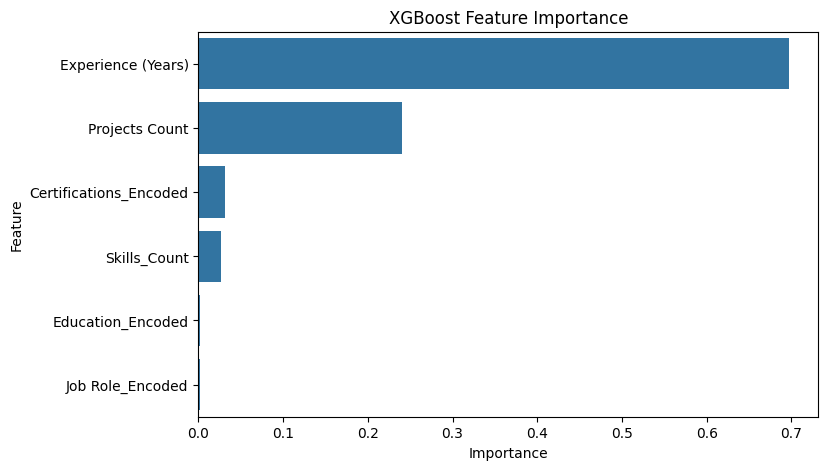

In [36]:
# plotting

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.show()

In [37]:
# save the final model 

import joblib

joblib.dump(xgb_model, "ai_score_predictor.pkl")

['ai_score_predictor.pkl']

In [38]:
# save encoders

joblib.dump(le_cert, "cert_encoder.pkl")
joblib.dump(le_job, "job_encoder.pkl")
joblib.dump(encoder, "education_encoder.pkl")

['education_encoder.pkl']

In [40]:
# models saved in pkl files

import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Master dictionary to keep models alive in memory
trained_models = {}

# ==================================================
# Training Scaled Models
# ==================================================
models_scaled = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Support Vector Regression": SVR(),
}

for name, model in models_scaled.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
    
    # Keep a reference to the trained model
    trained_models[name] = model

# ==================================================
# Training Unscaled Models
# ==================================================
models_unscaled = {
    "Decision tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

for name, model in models_unscaled.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
    
    # Keep a reference to the trained model
    trained_models[name] = model


# ==================================================
# 🛠️ SAVE ALL MODELS AT THE VERY END
# ==================================================
print("\n--- Saving all models to pkl files ---")

joblib.dump(trained_models["Linear Regression"], "linear.pkl")
joblib.dump(trained_models["KNN Regressor"], "knn.pkl")
joblib.dump(trained_models["Support Vector Regression"], "svr.pkl")
joblib.dump(trained_models["Decision tree"], "dt.pkl")
joblib.dump(trained_models["Random Forest"], "rf.pkl")
joblib.dump(trained_models["XGBoost"], "xgb.pkl")

print("All 6 models successfully saved at the end of the script!")

Linear Regression -> MAE: 8.52, RMSE: 10.17, R2: 0.81
KNN Regressor -> MAE: 5.18, RMSE: 7.85, R2: 0.88
Support Vector Regression -> MAE: 7.41, RMSE: 11.05, R2: 0.77
Decision tree -> MAE: 2.05, RMSE: 4.33, R2: 0.96
Random Forest -> MAE: 1.69, RMSE: 2.87, R2: 0.98
XGBoost -> MAE: 1.04, RMSE: 1.75, R2: 0.99

--- Saving all models to pkl files ---
All 6 models successfully saved at the end of the script!


In [ ]:
# verify saved files

import os

print(os.listdir())

['AI_Resume_Screening.csv', 'ai_score_predictor.pkl', 'cert_encoder.pkl', 'education_encoder.pkl', 'job_encoder.pkl', 'screening_Analysis.ipynb']


In [ ]:
# test with new data

education_encoded = encoder.transform([['mtech']])[0][0]

cert_encoded = le_cert.transform(['cloud'])[0]

job_encoded = le_job.transform(['data scientist'])[0]

new_candidate = pd.DataFrame({
    'Experience (Years)': [3],
    'Projects Count': [3],
    'Education_Encoded': [2],      # BTech
    'Certifications_Encoded': [2], # None
    'Job Role_Encoded': [3],       # Software Engineer
    'Skills_Count': [4]
})

predicted_score = xgb_model.predict(new_candidate)[0]

print(f"Predicted AI Score: {predicted_score:.2f}")

Predicted AI Score: 67.32


e:\vscode\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


In [ ]:
new_candidate

,Experience (Years),Projects Count,Education_Encoded,Certifications_Encoded,Job Role_Encoded,Skills_Count
0,5,6,4.0,0,2,8


In [ ]:
print(le_cert.classes_)
print(le_job.classes_)
print(encoder.categories_)

['cloud' 'data_science' 'none']
['ai researcher' 'cybersecurity analyst' 'data scientist'
 'software engineer']
[array(['unknown', 'bsc', 'btech', 'mba', 'mtech', 'phd'], dtype=object)]


In [ ]:
# another test strong

new_candidate = pd.DataFrame({
    'Experience (Years)': [4],
    'Projects Count': [4],
    'Education_Encoded': [3],      # MBA
    'Certifications_Encoded': [1], # Data Science
    'Job Role_Encoded': [2],       # Data Scientist
    'Skills_Count': [5]
})

predicted_score = xgb_model.predict(new_candidate)[0]

print(f"Predicted AI Score: {predicted_score:.2f}")

Predicted AI Score: 89.59


In [ ]:
# other sample beginner

new_candidate = pd.DataFrame({
    'Experience (Years)': [1],
    'Projects Count': [1],
    'Education_Encoded': [1],      # BSc
    'Certifications_Encoded': [2], # None
    'Job Role_Encoded': [3],       # Software Engineer
    'Skills_Count': [2]
})

predicted_score = xgb_model.predict(new_candidate)[0]

print(f"Predicted AI Score: {predicted_score:.2f}")

Predicted AI Score: 30.70
